# Chapter 7.4: Multi-Agent Recommendation

## Learning Objectives

By the end of this notebook, you will be able to:

1. Design multi-agent architectures with user, item, and platform agents
2. Implement collaborative agent protocols for recommendation
3. Build user simulation agents for training and evaluation
4. Create negotiation-based recommendation systems for multiple stakeholders
5. Implement debate-style recommendation where agents argue for different items
6. Evaluate multi-agent systems for recommendation quality and fairness
7. Understand the trade-offs between single-agent and multi-agent designs

## Prerequisites

- Chapter 7.3 (LLM Agents for Recommendation)
- Basic understanding of multi-agent systems
- Python OOP (classes, inheritance)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part7/chapter_7.4_multi_agent.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part7/chapter_7.4_multi_agent.ipynb)

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional, Any
from dataclasses import dataclass, field
from collections import defaultdict
import json

np.random.seed(42)
random.seed(42)

plt.style.use('seaborn-v0_8')
print("All imports successful.")

All imports successful.


## 1. Multi-Agent Architectures for Recommendation

Traditional rec systems use a single model. Multi-agent systems decompose the problem into specialized agents:

- **User Agent**: Represents user interests, preferences, and constraints
- **Item Agent**: Represents item properties, handles item-side optimization
- **Platform Agent**: Mediates between users and items, enforces fairness and business rules

$$\text{Recommendation} = \text{Platform}\left(\text{User}(u) \leftrightarrow \text{Item}(i)\right)$$

> **💡 Concept:** Multi-agent systems can model the **multiple stakeholders** in recommendation: users want relevant content, content creators want exposure, and the platform wants engagement + fairness. Each agent optimizes for its stakeholder while negotiating with others.

In [2]:
# Shared data structures
@dataclass
class Item:
    item_id: int
    name: str
    category: str
    quality: float  # 0-1
    popularity: float  # 0-1
    creator_id: int
    tags: List[str] = field(default_factory=list)

@dataclass
class User:
    user_id: int
    preferences: Dict[str, float]  # tag -> preference score
    history: List[int] = field(default_factory=list)
    satisfaction_history: List[float] = field(default_factory=list)


def create_environment(n_users: int = 50, n_items: int = 100, n_creators: int = 10):
    """Create a multi-agent recommendation environment."""
    rng = np.random.RandomState(42)
    
    all_tags = ['action', 'comedy', 'drama', 'sci-fi', 'romance', 
                'thriller', 'documentary', 'animation', 'horror', 'musical']
    categories = ['Movie', 'Series', 'Documentary', 'Short']
    
    items = []
    for i in range(n_items):
        n_tags = rng.randint(1, 4)
        tags = list(rng.choice(all_tags, n_tags, replace=False))
        items.append(Item(
            item_id=i,
            name=f"Content_{i}",
            category=categories[i % len(categories)],
            quality=rng.beta(2, 2),
            popularity=rng.beta(1, 3),  # Most items have low popularity
            creator_id=i % n_creators,
            tags=tags
        ))
    
    users = []
    for u in range(n_users):
        prefs = {}
        liked_tags = list(rng.choice(all_tags, rng.randint(2, 5), replace=False))
        for tag in all_tags:
            if tag in liked_tags:
                prefs[tag] = rng.uniform(0.5, 1.0)
            else:
                prefs[tag] = rng.uniform(-0.5, 0.3)
        users.append(User(user_id=u, preferences=prefs))
    
    return users, items, all_tags


users, items, all_tags = create_environment()
print(f"Created {len(users)} users, {len(items)} items")
print(f"Sample item: {items[0]}")
print(f"Sample user preferences: {dict(list(users[0].preferences.items())[:5])}")

Created 50 users, 100 items
Sample item: Item(item_id=0, name='Content_0', category='Movie', quality=0.38064829699136865, popularity=0.6399545258238164, creator_id=0, tags=['thriller', 'action', 'musical'])
Sample user preferences: {'action': 0.23494223759480348, 'comedy': 0.800304771273118, 'drama': 0.25270028507045195, 'sci-fi': 0.16147110696950195, 'romance': 0.8334857584954536}


In [3]:
class UserAgent:
    """Agent representing user interests."""
    
    def __init__(self, user: User):
        self.user = user
    
    def score_item(self, item: Item) -> float:
        """Score an item from the user's perspective."""
        score = 0.0
        for tag in item.tags:
            score += self.user.preferences.get(tag, 0.0)
        # Normalize by number of tags
        score = score / max(len(item.tags), 1)
        # Penalize already seen items
        if item.item_id in self.user.history:
            score *= 0.1
        return score
    
    def get_top_preferences(self, n: int = 3) -> List[str]:
        sorted_prefs = sorted(self.user.preferences.items(), key=lambda x: -x[1])
        return [tag for tag, score in sorted_prefs[:n]]
    
    def provide_feedback(self, item: Item) -> float:
        """Simulate user rating for an item."""
        base_score = self.score_item(item)
        # Add quality influence and noise
        rating = base_score * 0.6 + item.quality * 0.4 + np.random.normal(0, 0.1)
        rating = np.clip(rating, 0, 1)
        self.user.satisfaction_history.append(rating)
        return rating


class ItemAgent:
    """Agent representing item/creator interests."""
    
    def __init__(self, items: List[Item], creator_id: int):
        self.items = [i for i in items if i.creator_id == creator_id]
        self.creator_id = creator_id
        self.exposure_counts = defaultdict(int)
    
    def get_items_to_promote(self, n: int = 3) -> List[Item]:
        """Select items that need more exposure."""
        # Prioritize high-quality items with low exposure
        scored = []
        for item in self.items:
            exposure = self.exposure_counts[item.item_id]
            promotion_score = item.quality * 0.7 - np.log1p(exposure) * 0.3
            scored.append((item, promotion_score))
        scored.sort(key=lambda x: -x[1])
        return [item for item, score in scored[:n]]
    
    def register_exposure(self, item_id: int):
        self.exposure_counts[item_id] += 1


class PlatformAgent:
    """Agent representing platform objectives (fairness, diversity, engagement)."""
    
    def __init__(self, items: List[Item], 
                 diversity_weight: float = 0.3,
                 fairness_weight: float = 0.2):
        self.items = items
        self.diversity_weight = diversity_weight
        self.fairness_weight = fairness_weight
        self.creator_exposure = defaultdict(int)
        self.category_exposure = defaultdict(int)
    
    def mediate(self, user_scores: Dict[int, float], 
                item_promotions: Dict[int, float],
                top_k: int = 5) -> List[int]:
        """Mediate between user and item agents to produce final ranking."""
        combined_scores = {}
        
        for item in self.items:
            iid = item.item_id
            user_score = user_scores.get(iid, 0.0)
            promotion_score = item_promotions.get(iid, 0.0)
            
            # Diversity bonus
            cat_count = self.category_exposure.get(item.category, 0)
            diversity_bonus = 1.0 / (1.0 + cat_count * 0.1)
            
            # Fairness bonus (for underexposed creators)
            creator_count = self.creator_exposure.get(item.creator_id, 0)
            fairness_bonus = 1.0 / (1.0 + creator_count * 0.1)
            
            combined = (
                (1 - self.diversity_weight - self.fairness_weight) * user_score +
                self.diversity_weight * diversity_bonus +
                self.fairness_weight * fairness_bonus +
                0.1 * promotion_score
            )
            combined_scores[iid] = combined
        
        # Select top-K with diversity constraint
        ranked = sorted(combined_scores.items(), key=lambda x: -x[1])
        selected = []
        selected_categories = set()
        
        for item_id, score in ranked:
            item = self.items[item_id]
            # Allow at most 2 items per category
            if sum(1 for c in selected_categories if c == item.category) < 2:
                selected.append(item_id)
                selected_categories.add(item.category)
            if len(selected) >= top_k:
                break
        
        # Update exposure counts
        for iid in selected:
            item = self.items[iid]
            self.creator_exposure[item.creator_id] += 1
            self.category_exposure[item.category] += 1
        
        return selected


# Demo multi-agent recommendation
user_agent = UserAgent(users[0])
item_agents = {cid: ItemAgent(items, cid) for cid in range(10)}
platform_agent = PlatformAgent(items)

# User agent scores all items
user_scores = {item.item_id: user_agent.score_item(item) for item in items}

# Item agents promote their best items
item_promotions = {}
for cid, ia in item_agents.items():
    for item in ia.get_items_to_promote(3):
        item_promotions[item.item_id] = item.quality

# Platform mediates
recommended_ids = platform_agent.mediate(user_scores, item_promotions, top_k=5)

print("Multi-Agent Recommendation:")
print(f"User top preferences: {user_agent.get_top_preferences(3)}")
print(f"\nRecommended items:")
for iid in recommended_ids:
    item = items[iid]
    print(f"  {item.name} | Cat: {item.category} | Tags: {item.tags} | "
          f"Quality: {item.quality:.2f} | Creator: {item.creator_id}")

Multi-Agent Recommendation:
User top preferences: ['romance', 'horror', 'comedy']

Recommended items:
  Content_46 | Cat: Documentary | Tags: ['romance'] | Quality: 0.66 | Creator: 6
  Content_97 | Cat: Series | Tags: ['comedy'] | Quality: 0.78 | Creator: 7
  Content_90 | Cat: Documentary | Tags: ['romance'] | Quality: 0.61 | Creator: 0
  Content_1 | Cat: Series | Tags: ['comedy'] | Quality: 0.77 | Creator: 1
  Content_57 | Cat: Series | Tags: ['horror'] | Quality: 0.73 | Creator: 7


## 2. User Simulation Agents

User simulation agents are crucial for:
1. **Training** RL-based recommenders without real users
2. **Evaluating** recommendation quality at scale
3. **Testing** edge cases and failure modes

A good user simulator models:
- Preference dynamics (changing interests over time)
- Behavioral patterns (binge-watching, browsing, etc.)
- Feedback noise (not all clicks are intentional)

> **⚠️ Common Pitfall:** User simulators can introduce systematic biases. If the simulator is too simple, policies trained on it may not transfer to real users. Always validate with real A/B tests.

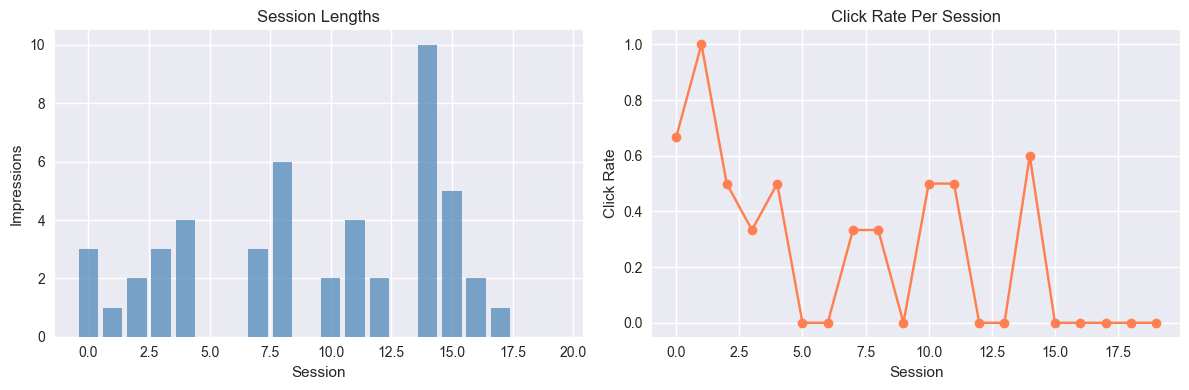

In [4]:
class UserSimulator:
    """Simulated user with evolving preferences."""
    
    def __init__(self, user: User, seed: int = 42):
        self.user = user
        self.rng = np.random.RandomState(seed + user.user_id)
        self.base_preferences = dict(user.preferences)
        self.current_preferences = dict(user.preferences)
        self.mood_state = 0.0  # -1 (bored) to 1 (engaged)
        self.session_items = []
        self.fatigue = 0.0
    
    def start_session(self):
        """Start a new browsing session."""
        self.session_items = []
        self.mood_state = self.rng.uniform(-0.3, 0.5)
        self.fatigue = 0.0
        # Slight preference drift each session
        for tag in self.current_preferences:
            drift = self.rng.normal(0, 0.05)
            self.current_preferences[tag] = np.clip(
                self.current_preferences[tag] + drift, -1, 1
            )
    
    def decide_click(self, item: Item) -> bool:
        """Decide whether to click on a recommended item."""
        relevance = sum(self.current_preferences.get(t, 0) for t in item.tags)
        relevance /= max(len(item.tags), 1)
        
        # Click probability influenced by relevance, mood, fatigue, and item popularity
        click_prob = (
            0.3 * (relevance + 1) / 2 +  # Relevance [0, 1]
            0.2 * (self.mood_state + 1) / 2 +  # Mood [0, 1]
            0.2 * item.popularity +
            0.1 * item.quality -
            0.2 * self.fatigue
        )
        click_prob = np.clip(click_prob, 0.01, 0.95)
        
        clicked = self.rng.random() < click_prob
        
        # Update state
        if clicked:
            self.mood_state = min(1, self.mood_state + 0.1)
            self.session_items.append(item.item_id)
            # Preference reinforcement
            for tag in item.tags:
                self.current_preferences[tag] = min(
                    1, self.current_preferences.get(tag, 0) + 0.02
                )
        else:
            self.mood_state = max(-1, self.mood_state - 0.05)
        
        self.fatigue = min(1, self.fatigue + 0.03)
        return clicked
    
    def rate_item(self, item: Item) -> float:
        """Rate an item (1-5 scale)."""
        relevance = sum(self.current_preferences.get(t, 0) for t in item.tags)
        relevance /= max(len(item.tags), 1)
        
        rating = 3.0 + relevance * 1.5 + item.quality * 0.5 + self.rng.normal(0, 0.3)
        return round(np.clip(rating, 1.0, 5.0), 1)
    
    def will_continue_session(self) -> bool:
        """Decide whether to continue browsing."""
        continue_prob = max(0.1, 0.8 - self.fatigue * 0.5 - max(0, -self.mood_state) * 0.3)
        return self.rng.random() < continue_prob


# Run simulation
simulator = UserSimulator(users[0])
session_lengths = []
click_rates = []

for session in range(20):
    simulator.start_session()
    clicks = 0
    impressions = 0
    
    while simulator.will_continue_session() and impressions < 30:
        # Random recommendation for now
        item = items[np.random.randint(len(items))]
        impressions += 1
        if simulator.decide_click(item):
            clicks += 1
    
    session_lengths.append(impressions)
    click_rates.append(clicks / max(impressions, 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(len(session_lengths)), session_lengths, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Session')
axes[0].set_ylabel('Impressions')
axes[0].set_title('Session Lengths')

axes[1].plot(click_rates, marker='o', color='coral')
axes[1].set_xlabel('Session')
axes[1].set_ylabel('Click Rate')
axes[1].set_title('Click Rate Per Session')

plt.tight_layout()
plt.show()

## 3. Negotiation-Based Recommendation

In a multi-stakeholder setting, agents can **negotiate** to find recommendations that balance competing interests.

The negotiation protocol:
1. Each agent proposes a set of items
2. Agents evaluate each other's proposals
3. Through iterative rounds, agents converge on a compromise

$$\text{Agreement} = \arg\max_{S \subseteq \mathcal{I}} \sum_{a \in \text{Agents}} w_a \cdot U_a(S)$$

where $U_a(S)$ is agent $a$'s utility for recommendation set $S$.

In [5]:
class NegotiationProtocol:
    """Multi-agent negotiation for recommendation."""
    
    def __init__(self, user_agent: UserAgent, item_agents: Dict[int, ItemAgent],
                 platform_agent: PlatformAgent, items: List[Item],
                 max_rounds: int = 5):
        self.user_agent = user_agent
        self.item_agents = item_agents
        self.platform_agent = platform_agent
        self.items = items
        self.max_rounds = max_rounds
        self.negotiation_log = []
    
    def negotiate(self, top_k: int = 5) -> Tuple[List[int], List[Dict]]:
        """Run negotiation protocol."""
        self.negotiation_log = []
        
        # Initial proposals
        user_proposal = self._get_user_proposal(top_k * 2)
        item_proposals = self._get_item_proposals(top_k)
        
        current_selection = list(set(user_proposal[:top_k]))
        
        for round_num in range(self.max_rounds):
            round_log = {'round': round_num + 1, 'events': []}
            
            # User agent evaluates current selection
            user_utilities = {
                iid: self.user_agent.score_item(self.items[iid]) 
                for iid in current_selection
            }
            avg_user_utility = np.mean(list(user_utilities.values())) if user_utilities else 0
            round_log['events'].append(f"User utility: {avg_user_utility:.3f}")
            
            # Item agents propose swaps for underexposed items
            swap_proposals = []
            for cid, ia in self.item_agents.items():
                promoted = ia.get_items_to_promote(1)
                for item in promoted:
                    if item.item_id not in current_selection:
                        swap_proposals.append(item.item_id)
            
            # Platform agent evaluates and decides on swaps
            if swap_proposals:
                # Find the weakest item in current selection
                weakest = min(current_selection, key=lambda x: user_utilities.get(x, 0))
                # Try to swap with the best promoted item
                best_swap = max(swap_proposals, 
                               key=lambda x: self.items[x].quality * 0.5 + 
                               (1 if self.items[x].creator_id not in 
                                {self.items[s].creator_id for s in current_selection} else 0) * 0.5)
                
                # Accept swap if it doesn't hurt user utility too much
                swap_user_score = self.user_agent.score_item(self.items[best_swap])
                weakest_score = user_utilities.get(weakest, 0)
                
                if swap_user_score > weakest_score * 0.7:  # Allow slight quality loss
                    current_selection.remove(weakest)
                    current_selection.append(best_swap)
                    round_log['events'].append(
                        f"Swap: {self.items[weakest].name} -> {self.items[best_swap].name}"
                    )
                else:
                    round_log['events'].append("No swap accepted (user utility too low)")
            
            self.negotiation_log.append(round_log)
        
        return current_selection[:top_k], self.negotiation_log
    
    def _get_user_proposal(self, n: int) -> List[int]:
        scored = [(item.item_id, self.user_agent.score_item(item)) for item in self.items]
        scored.sort(key=lambda x: -x[1])
        return [iid for iid, score in scored[:n]]
    
    def _get_item_proposals(self, n: int) -> List[int]:
        proposals = []
        for cid, ia in self.item_agents.items():
            for item in ia.get_items_to_promote(1):
                proposals.append(item.item_id)
        return proposals[:n]


# Run negotiation
user_agent = UserAgent(users[0])
item_agents = {cid: ItemAgent(items, cid) for cid in range(10)}
platform_agent = PlatformAgent(items)

protocol = NegotiationProtocol(user_agent, item_agents, platform_agent, items)
negotiated_ids, log = protocol.negotiate(top_k=5)

print("Negotiation Log:")
for entry in log:
    print(f"  Round {entry['round']}: {', '.join(entry['events'])}")

print(f"\nFinal Recommendations:")
for iid in negotiated_ids:
    item = items[iid]
    score = user_agent.score_item(item)
    print(f"  {item.name} | Cat: {item.category} | Creator: {item.creator_id} | "
          f"Quality: {item.quality:.2f} | User Score: {score:.3f}")

Negotiation Log:
  Round 1: User utility: 0.827, No swap accepted (user utility too low)
  Round 2: User utility: 0.827, No swap accepted (user utility too low)
  Round 3: User utility: 0.827, No swap accepted (user utility too low)
  Round 4: User utility: 0.827, No swap accepted (user utility too low)
  Round 5: User utility: 0.827, No swap accepted (user utility too low)

Final Recommendations:
  Content_11 | Cat: Short | Creator: 1 | Quality: 0.39 | User Score: 0.817
  Content_75 | Cat: Short | Creator: 5 | Quality: 0.35 | User Score: 0.818
  Content_46 | Cat: Documentary | Creator: 6 | Quality: 0.66 | User Score: 0.833
  Content_85 | Cat: Series | Creator: 5 | Quality: 0.48 | User Score: 0.833
  Content_90 | Cat: Documentary | Creator: 0 | Quality: 0.61 | User Score: 0.833


## 4. Debate-Style Recommendation

In debate-style recommendation, multiple agents **argue** for different items, providing reasons and counterarguments. The final selection is based on the quality of arguments.

This approach:
- Generates diverse perspectives on items
- Produces natural explanations as a byproduct
- Can surface non-obvious item qualities

> **🔑 Pro Tip:** Debate-style recommendation is particularly useful when items have complex trade-offs (e.g., movies with divisive reviews, products with trade-offs between features).

In [6]:
class DebateAgent:
    """Agent that argues for a specific item."""
    
    def __init__(self, agent_id: int, assigned_item: Item, all_items: List[Item]):
        self.agent_id = agent_id
        self.item = assigned_item
        self.all_items = all_items
        self.arguments: List[str] = []
    
    def make_argument(self, user_prefs: Dict[str, float]) -> Dict[str, Any]:
        """Generate arguments for why this item should be recommended."""
        strengths = []
        relevance_score = 0.0
        
        # Preference matching
        matching_tags = []
        for tag in self.item.tags:
            pref = user_prefs.get(tag, 0)
            if pref > 0.3:
                matching_tags.append(tag)
                relevance_score += pref
        
        if matching_tags:
            strengths.append(f"Matches user interests: {', '.join(matching_tags)}")
        
        # Quality argument
        if self.item.quality > 0.7:
            strengths.append(f"High quality content (score: {self.item.quality:.2f})")
        
        # Novelty argument
        if self.item.popularity < 0.3:
            strengths.append("Hidden gem - not widely discovered yet")
        
        # Category diversity
        strengths.append(f"Category: {self.item.category}")
        
        argument = {
            'item': self.item,
            'strengths': strengths,
            'relevance_score': relevance_score / max(len(self.item.tags), 1),
            'quality_score': self.item.quality,
            'novelty_score': 1 - self.item.popularity,
            'overall': (relevance_score / max(len(self.item.tags), 1)) * 0.5 + 
                       self.item.quality * 0.3 + (1 - self.item.popularity) * 0.2
        }
        self.arguments.append(argument)
        return argument
    
    def counter_argue(self, opponent_argument: Dict) -> str:
        """Generate counter-argument against another item."""
        opp_item = opponent_argument['item']
        counters = []
        
        if opp_item.quality < self.item.quality:
            counters.append(
                f"{self.item.name} has higher quality ({self.item.quality:.2f} vs {opp_item.quality:.2f})"
            )
        if opp_item.popularity > 0.5 and self.item.popularity < 0.3:
            counters.append(
                f"{opp_item.name} is mainstream, while {self.item.name} offers fresh discovery"
            )
        
        return "; ".join(counters) if counters else "No strong counter-arguments."


class DebateJudge:
    """Judge that evaluates debate arguments and selects winners."""
    
    def __init__(self, relevance_weight: float = 0.5, 
                 quality_weight: float = 0.3, novelty_weight: float = 0.2):
        self.weights = {
            'relevance': relevance_weight,
            'quality': quality_weight,
            'novelty': novelty_weight
        }
    
    def judge_debate(self, arguments: List[Dict], top_k: int = 3) -> List[Dict]:
        """Select the best items from debate arguments."""
        scored = []
        for arg in arguments:
            final_score = (
                self.weights['relevance'] * arg['relevance_score'] +
                self.weights['quality'] * arg['quality_score'] +
                self.weights['novelty'] * arg['novelty_score']
            )
            # Bonus for number of strong arguments
            final_score += 0.05 * len(arg['strengths'])
            scored.append({**arg, 'final_score': final_score})
        
        scored.sort(key=lambda x: -x['final_score'])
        return scored[:top_k]


# Run a debate
user_prefs = users[0].preferences
candidate_items = random.sample(items, 10)  # 10 items compete

# Create debate agents
debate_agents = [DebateAgent(i, item, items) for i, item in enumerate(candidate_items)]

# Round 1: Each agent makes their case
arguments = []
print("=== DEBATE ROUND 1: Opening Arguments ===")
for agent in debate_agents:
    arg = agent.make_argument(user_prefs)
    arguments.append(arg)
    print(f"\n[Agent {agent.agent_id}] Arguing for {agent.item.name}:")
    for s in arg['strengths']:
        print(f"  + {s}")
    print(f"  Overall score: {arg['overall']:.3f}")

# Round 2: Counter-arguments (top 5 vs each other)
print("\n=== DEBATE ROUND 2: Counter-Arguments ===")
top_5_args = sorted(arguments, key=lambda x: -x['overall'])[:5]
for i, arg1 in enumerate(top_5_args):
    for j, arg2 in enumerate(top_5_args):
        if i != j:
            agent = debate_agents[arguments.index(arg1)]
            counter = agent.counter_argue(arg2)
            if counter != "No strong counter-arguments.":
                print(f"  {arg1['item'].name} vs {arg2['item'].name}: {counter}")

# Judge decides
judge = DebateJudge()
winners = judge.judge_debate(arguments, top_k=3)

print("\n=== JUDGE'S VERDICT ===")
for i, w in enumerate(winners, 1):
    print(f"  {i}. {w['item'].name} (score: {w['final_score']:.3f})")
    print(f"     Reasons: {'; '.join(w['strengths'])}")

=== DEBATE ROUND 1: Opening Arguments ===

[Agent 0] Arguing for Content_81:
  + Hidden gem - not widely discovered yet
  + Category: Series
  Overall score: 0.308

[Agent 1] Arguing for Content_14:
  + Matches user interests: comedy, horror
  + Category: Documentary
  Overall score: 0.592

[Agent 2] Arguing for Content_3:
  + Hidden gem - not widely discovered yet
  + Category: Short
  Overall score: 0.270

[Agent 3] Arguing for Content_94:
  + Hidden gem - not widely discovered yet
  + Category: Documentary
  Overall score: 0.225

[Agent 4] Arguing for Content_35:
  + Matches user interests: horror
  + High quality content (score: 0.80)
  + Category: Short
  Overall score: 0.776

[Agent 5] Arguing for Content_31:
  + Category: Short
  Overall score: 0.205

[Agent 6] Arguing for Content_28:
  + Matches user interests: comedy
  + Hidden gem - not widely discovered yet
  + Category: Movie
  Overall score: 0.535

[Agent 7] Arguing for Content_17:
  + Matches user interests: comedy
  + Hi

## 5. Multi-Agent System Evaluation

We compare single-agent vs multi-agent approaches across multiple metrics.

Running single...
  Satisfaction: 0.837, Diversity: 0.560, Novelty: 0.729, Fairness: 0.632
Running multi_agent...
  Satisfaction: 0.817, Diversity: 0.520, Novelty: 0.753, Fairness: 0.764
Running negotiation...


  Satisfaction: 0.835, Diversity: 0.540, Novelty: 0.731, Fairness: 0.693


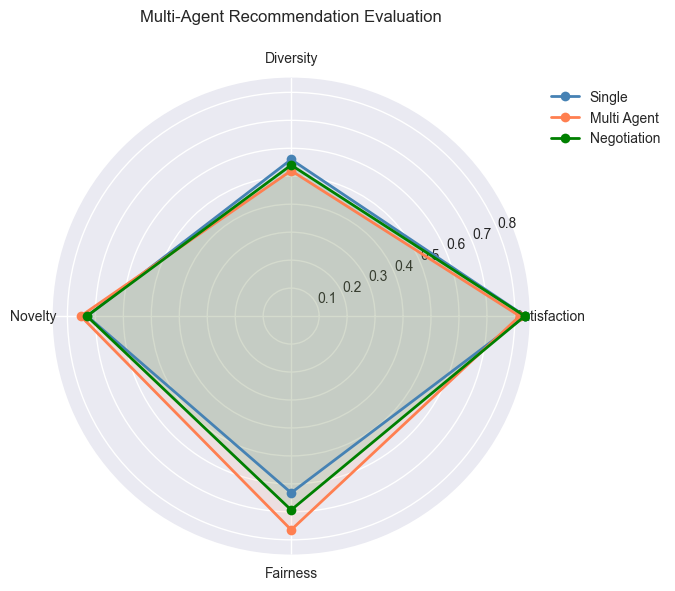

In [7]:
def run_simulation(users, items, n_sessions: int = 20, approach: str = 'single'):
    """Run a full simulation comparing approaches."""
    metrics = {'satisfaction': [], 'diversity': [], 'fairness': [], 'novelty': []}
    creator_total_exposure = defaultdict(int)
    
    for session in range(n_sessions):
        for user in users[:10]:
            if approach == 'single':
                # Pure relevance-based
                ua = UserAgent(user)
                scored = [(item.item_id, ua.score_item(item)) for item in items]
                scored.sort(key=lambda x: -x[1])
                rec_ids = [iid for iid, s in scored[:5]]
            
            elif approach == 'multi_agent':
                ua = UserAgent(user)
                ia = {cid: ItemAgent(items, cid) for cid in range(10)}
                pa = PlatformAgent(items, diversity_weight=0.3, fairness_weight=0.2)
                
                user_scores = {item.item_id: ua.score_item(item) for item in items}
                item_promos = {}
                for cid, agent in ia.items():
                    for itm in agent.get_items_to_promote(2):
                        item_promos[itm.item_id] = itm.quality
                
                rec_ids = pa.mediate(user_scores, item_promos, top_k=5)
            
            elif approach == 'negotiation':
                ua = UserAgent(user)
                ia = {cid: ItemAgent(items, cid) for cid in range(10)}
                pa = PlatformAgent(items)
                protocol = NegotiationProtocol(ua, ia, pa, items, max_rounds=3)
                rec_ids, _ = protocol.negotiate(top_k=5)
            
            # Compute metrics
            rec_items = [items[iid] for iid in rec_ids]
            
            # Satisfaction
            ua_tmp = UserAgent(user)
            sats = [ua_tmp.score_item(item) for item in rec_items]
            metrics['satisfaction'].append(np.mean(sats))
            
            # Diversity
            cats = set(item.category for item in rec_items)
            metrics['diversity'].append(len(cats) / len(rec_items))
            
            # Novelty (inverse popularity)
            novelty = np.mean([1 - item.popularity for item in rec_items])
            metrics['novelty'].append(novelty)
            
            # Track creator exposure
            for item in rec_items:
                creator_total_exposure[item.creator_id] += 1
    
    # Fairness: Gini coefficient of creator exposure
    exposures = np.array(list(creator_total_exposure.values()))
    if len(exposures) > 0 and exposures.sum() > 0:
        sorted_exp = np.sort(exposures)
        n = len(sorted_exp)
        cumulative = np.cumsum(sorted_exp)
        gini = (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n
        gini = max(0, gini)
    else:
        gini = 0
    
    return {
        'satisfaction': np.mean(metrics['satisfaction']),
        'diversity': np.mean(metrics['diversity']),
        'novelty': np.mean(metrics['novelty']),
        'fairness': 1 - gini  # Higher = more fair
    }


# Compare approaches
approaches = ['single', 'multi_agent', 'negotiation']
all_results = {}

for approach in approaches:
    print(f"Running {approach}...")
    result = run_simulation(users, items, n_sessions=10, approach=approach)
    all_results[approach] = result
    print(f"  Satisfaction: {result['satisfaction']:.3f}, Diversity: {result['diversity']:.3f}, "
          f"Novelty: {result['novelty']:.3f}, Fairness: {result['fairness']:.3f}")

# Radar chart comparison
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))
metric_names = ['Satisfaction', 'Diversity', 'Novelty', 'Fairness']
angles = np.linspace(0, 2 * np.pi, len(metric_names), endpoint=False).tolist()
angles += angles[:1]

colors = ['steelblue', 'coral', 'green']
for idx, (approach, result) in enumerate(all_results.items()):
    values = [result['satisfaction'], result['diversity'], result['novelty'], result['fairness']]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=approach.replace('_', ' ').title(), color=colors[idx])
    ax.fill(angles, values, alpha=0.1, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_names)
ax.set_title('Multi-Agent Recommendation Evaluation', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

## 6. Summary

| Architecture | Strengths | Weaknesses | Best For |
|-------------|-----------|------------|----------|
| Single Agent | Simple, fast | No stakeholder balance | Simple personalization |
| Multi-Agent | Fair, diverse | Complex coordination | Multi-stakeholder platforms |
| Negotiation | Balanced outcomes | Slower convergence | Marketplace settings |
| Debate | Explanatory | Requires diverse agents | Complex item trade-offs |

**Key references:**
- Zhang et al. (2023) - Multi-agent recommendation systems survey
- Wang et al. (2023) - RecAgent user simulation
- Irving et al. (2018) - AI Safety via Debate (DeepMind)
- Du et al. (2023) - Multi-agent debate for reasoning

---

## Exercises

### 🏋️ Exercise 1: Build a Multi-Agent Rec System with User Simulator

In [8]:
# 🏋️ Exercise 1: Complete multi-agent system with user simulator

class AdaptiveMultiAgentSystem:
    """Multi-agent system that adapts based on user simulator feedback."""
    
    def __init__(self, items: List[Item], n_creators: int = 10):
        self.items = items
        self.item_agents = {cid: ItemAgent(items, cid) for cid in range(n_creators)}
        # TODO: Initialize platform agent with adaptive weights
        self.platform_agent = None
        self.performance_history = []
    
    def recommend(self, user: User, simulator: UserSimulator, top_k: int = 5) -> List[int]:
        # TODO: Use multi-agent collaboration to generate recommendations
        # Then use simulator feedback to adapt weights
        pass
    
    def adapt_weights(self, satisfaction: float, diversity: float):
        # TODO: Adjust platform agent weights based on metrics
        pass

# TODO: Run 50 sessions and plot how the system adapts over time

print("Exercise 1: Implement AdaptiveMultiAgentSystem")

Exercise 1: Implement AdaptiveMultiAgentSystem


### 🏋️ Exercise 2: Auction-Based Recommendation

In [9]:
# 🏋️ Exercise 2: Auction-based recommendation

class AuctionRecommender:
    """Items bid for recommendation slots."""
    
    def __init__(self, items: List[Item]):
        self.items = items
        # TODO: Each item has a budget and bids for slots
        self.budgets = {item.item_id: item.quality * 100 for item in items}
    
    def run_auction(self, user: User, n_slots: int = 5) -> List[int]:
        # TODO: Implement a second-price auction where:
        # - Items bid based on their quality and user relevance
        # - Winners pay second-highest bid
        # - Budget is deducted
        pass

print("Exercise 2: Implement AuctionRecommender")

Exercise 2: Implement AuctionRecommender


### 🏋️ Exercise 3: Agent Communication Protocol

In [10]:
# 🏋️ Exercise 3: Design a structured communication protocol

class AgentMessage:
    """Structured message between agents."""
    def __init__(self, sender: str, receiver: str, msg_type: str, content: Dict):
        self.sender = sender
        self.receiver = receiver
        self.msg_type = msg_type  # 'proposal', 'accept', 'reject', 'counter'
        self.content = content

class CommunicatingAgent:
    """Agent that communicates via structured messages."""
    
    def __init__(self, agent_id: str):
        self.agent_id = agent_id
        self.inbox: List[AgentMessage] = []
    
    def send(self, receiver: str, msg_type: str, content: Dict) -> AgentMessage:
        # TODO: Create and return a message
        pass
    
    def receive(self, message: AgentMessage):
        # TODO: Process incoming message
        pass
    
    def decide(self) -> AgentMessage:
        # TODO: Based on inbox, decide next action
        pass

# TODO: Implement a full communication round between 3 agents

print("Exercise 3: Implement agent communication protocol")

Exercise 3: Implement agent communication protocol
